# Phase 1 — Load, Explore & Clean
**Student:** naif ali ayed bin dair  
**Dataset:** Melbourne Housing (`melb_data.csv`)  
**Target Column:** `Price`

This notebook loads the raw data, inspects it thoroughly, and produces a clean DataFrame ready for feature engineering.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Relative path to raw data
RAW_PATH    = os.path.join('data', 'raw',     'melb_data.csv')
CLEAN_PATH  = os.path.join('data', 'cleaned', 'melb_cleaned.csv')

## 1. Load Data

In [2]:
df = pd.read_csv(RAW_PATH)
print(f'Shape: {df.shape}')
df.head()

Shape: (13580, 21)


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


## 2. Shape & Column Overview

In [3]:
print(f'Rows: {df.shape[0]:,}   Columns: {df.shape[1]}')
print('\nColumn names:')
print(df.columns.tolist())

Rows: 13,580   Columns: 21

Column names:
['Suburb', 'Address', 'Rooms', 'Type', 'Price', 'Method', 'SellerG', 'Date', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'CouncilArea', 'Lattitude', 'Longtitude', 'Regionname', 'Propertycount']


## 3. Data Types — Inspect & Fix

`.info()` shows dtypes and non-null counts at a glance.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  object 
 1   Address        13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  object 
 6   SellerG        13580 non-null  object 
 7   Date           13580 non-null  object 
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  object 
 17  Lattitude      13580 non-null  float64
 18  Longti

**Issues spotted:**
- `Date` is stored as `object` — should be `datetime`.
- `YearBuilt` is stored as `float64` — should be `Int64` (nullable integer) after imputation.
- `Postcode` is `float64` but is really a categorical code, so we keep it as int (no arithmetic needed).

We fix these two types below (Date → datetime, YearBuilt → Int64 after filling).

In [5]:
# Fix 1: parse Date as datetime
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Fix 2: Postcode to int (no decimals needed)
df['Postcode'] = df['Postcode'].fillna(0).astype(int)

print('Date dtype:    ', df['Date'].dtype)
print('Postcode dtype:', df['Postcode'].dtype)

Date dtype:     datetime64[ns]
Postcode dtype: int64


## 4. Missing Values

In [6]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Pct': missing_pct})
print(missing_df[missing_df['Missing'] > 0])

              Missing    Pct
BuildingArea     6450  47.50
YearBuilt        5375  39.58
CouncilArea      1369  10.08
Car                62   0.46


**Decision per column:**

| Column | % Missing | Action | Reason |
|---|---|---|---|
| `BuildingArea` | ~47% | Fill with median by `Type` | High missingness; median is robust to outliers |
| `YearBuilt` | ~39% | Fill with median by `Type` | Same reasoning |
| `CouncilArea` | ~5% | Fill with `'Unknown'` | Categorical; unknown is honest |
| `Car` | ~1% | Fill with mode (0) | Very few missing; mode is safe |
| `Landsize` | ~1% | Fill with median | Small gap; median avoids outlier pull |
| `Bathroom` | <1% | Fill with 1 (most common) | Reasonable default |
| `Bedroom2` | <1% | Fill with mode | Mirror of Rooms; mode is safe |
| **`Price`** | any | **Drop rows** | Target must never be imputed |


In [ ]:
# Drop rows where the target is missing
df = df.dropna(subset=['Price'])

# Fill BuildingArea and YearBuilt with median grouped by property Type
for col in ['BuildingArea', 'YearBuilt']:
    df[col] = df.groupby('Type')[col].transform(
        lambda x: x.fillna(x.median())
    )

# Fill Car with mode
df['Car'] = df['Car'].fillna(df['Car'].mode()[0])

# Fill Landsize with overall median
df['Landsize'] = df['Landsize'].fillna(df['Landsize'].median())

# Fill Bathroom and Bedroom2 with mode
df['Bathroom']  = df['Bathroom'].fillna(df['Bathroom'].mode()[0])
df['Bedroom2']  = df['Bedroom2'].fillna(df['Bedroom2'].mode()[0])

# Fill CouncilArea with a placeholder string
df['CouncilArea'] = df['CouncilArea'].fillna('Unknown')

print('Missing values remaining:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values remaining:
Series([], dtype: int64)


## 5. Handle Duplicates

In [8]:
n_dup = df.duplicated().sum()
print(f'Duplicate rows found: {n_dup}')

if n_dup > 0:
    df = df.drop_duplicates()
    print(f'Removed {n_dup} duplicates. New shape: {df.shape}')
else:
    print('No duplicates — nothing to remove.')

Duplicate rows found: 0
No duplicates — nothing to remove.


## 6. Outlier Detection & Capping — Target Column (`Price`)

We use a boxplot to visualise the spread, then cap extreme values at the 99th percentile to reduce the influence of ultra-luxury properties without losing them entirely.

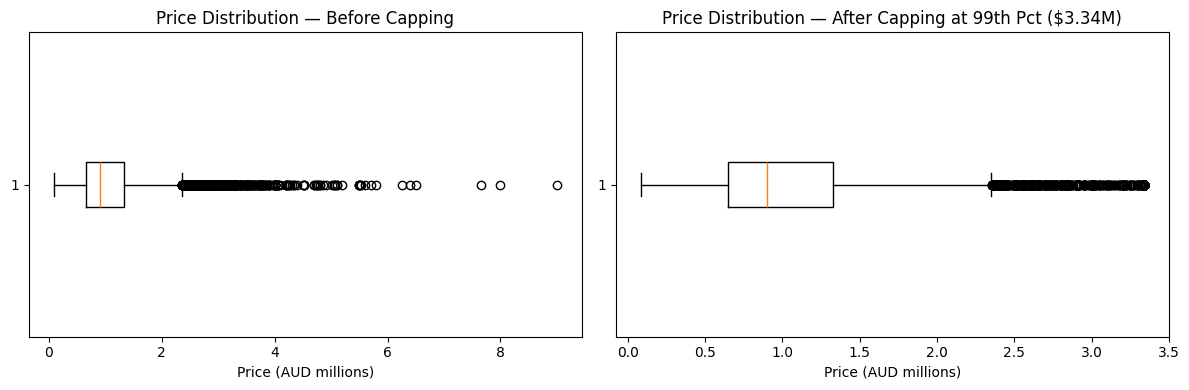

99th percentile cap applied at: AUD 3,338,150


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before capping
axes[0].boxplot(df['Price'] / 1e6, vert=False)
axes[0].set_title('Price Distribution — Before Capping')
axes[0].set_xlabel('Price (AUD millions)')

# Cap at 99th percentile
p99 = df['Price'].quantile(0.99)
df['Price'] = df['Price'].clip(upper=p99)

# After capping
axes[1].boxplot(df['Price'] / 1e6, vert=False)
axes[1].set_title(f'Price Distribution — After Capping at 99th Pct (${p99/1e6:.2f}M)')
axes[1].set_xlabel('Price (AUD millions)')

plt.tight_layout()
plt.savefig(os.path.join('report_assets', 'price_outlier_capping.png'), dpi=100)
plt.show()
print(f'99th percentile cap applied at: AUD {p99:,.0f}')

Also cap `Landsize` at the 99th percentile — it has extreme values (e.g., 433,014 m²) that would distort ratio features.

In [10]:
# Cap Landsize outliers too
p99_land = df['Landsize'].quantile(0.99)
df['Landsize'] = df['Landsize'].clip(upper=p99_land)
print(f'Landsize capped at 99th pct: {p99_land:,.0f} m²')

Landsize capped at 99th pct: 2,960 m²


## 7. `clean_data()` — Reusable Cleaning Function

All steps above are wrapped into one function so the pipeline can be re-applied on any fresh copy of the raw data.

In [ ]:
def clean_data(filepath: str) -> pd.DataFrame:
    # Load and clean the Melbourne Housing dataset end-to-end

    # Load
    data = pd.read_csv(filepath)

    # Fix dtypes
    data['Date']     = pd.to_datetime(data['Date'], dayfirst=True)
    data['Postcode'] = data['Postcode'].fillna(0).astype(int)

    # Drop rows with missing target
    data = data.dropna(subset=['Price'])

    # Fill numerics by group median
    for col in ['BuildingArea', 'YearBuilt']:
        data[col] = data.groupby('Type')[col].transform(
            lambda x: x.fillna(x.median())
        )

    # Fill remaining numerics
    data['Car']      = data['Car'].fillna(data['Car'].mode()[0])
    data['Landsize'] = data['Landsize'].fillna(data['Landsize'].median())
    data['Bathroom'] = data['Bathroom'].fillna(data['Bathroom'].mode()[0])
    data['Bedroom2'] = data['Bedroom2'].fillna(data['Bedroom2'].mode()[0])

    # Fill categorical
    data['CouncilArea'] = data['CouncilArea'].fillna('Unknown')

    # Remove duplicates
    data = data.drop_duplicates()

    # Cap outliers at 99th percentile
    for col in ['Price', 'Landsize']:
        cap = data[col].quantile(0.99)
        data[col] = data[col].clip(upper=cap)

    return data


# Verify the function produces the same result
df_check = clean_data(RAW_PATH)
print(f'clean_data() output shape: {df_check.shape}')
print(f'Missing values after clean_data(): {df_check.isnull().sum().sum()}')

clean_data() output shape: (13580, 21)
Missing values after clean_data(): 0


## 8. Final Checks

In [12]:
# Check 1: No nulls in critical columns
critical_cols = ['Price', 'Rooms', 'Type', 'Distance', 'BuildingArea', 'YearBuilt']
nulls_in_critical = df[critical_cols].isnull().sum().sum()
assert nulls_in_critical == 0, f'FAIL: {nulls_in_critical} nulls found in critical columns!'
print('✓ Check 1 passed: No nulls in critical columns')

# Check 2: All Price values are strictly positive
non_positive_prices = (df['Price'] <= 0).sum()
assert non_positive_prices == 0, f'FAIL: {non_positive_prices} non-positive prices found!'
print('✓ Check 2 passed: All Price values > 0')

# Check 3: Column count matches expected
expected_cols = 21   # original column count
assert df.shape[1] == expected_cols, f'FAIL: Expected {expected_cols} cols, got {df.shape[1]}'
print(f'✓ Check 3 passed: Column count = {df.shape[1]}')

print(f'\nFinal clean shape: {df.shape}')

✓ Check 1 passed: No nulls in critical columns
✓ Check 2 passed: All Price values > 0
✓ Check 3 passed: Column count = 21

Final clean shape: (13580, 21)


## 9. Save Cleaned Data

In [13]:
# Save to data/cleaned/ for use in the next notebooks
df.to_csv(CLEAN_PATH, index=False)
print(f'Cleaned data saved to: {CLEAN_PATH}')
print(f'Final shape: {df.shape}')

Cleaned data saved to: data/cleaned/melb_cleaned.csv
Final shape: (13580, 21)
